In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('/content/drive/MyDrive/ML Practice/Practice and test/data/Pearson.csv')
df

,Father,Son
0,65.0,59.8
1,63.3,63.2
2,65.0,63.3
3,65.8,62.8
4,61.1,64.3
...,...,...
1073,67.0,70.8
1074,71.3,68.3
1075,71.8,69.3
1076,70.7,69.3


In [3]:
X=df[['Father']]
y=df['Son']

In [4]:
import sklearn
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [5]:
training_data=pd.DataFrame({'X_train_values':X_train.to_numpy().ravel(),'y_train_values':y_train})
training_data

,X_train_values,y_train_values
875,64.4,65.2
949,66.9,67.7
618,72.0,71.8
881,67.4,64.8
590,65.8,71.0
...,...,...
330,67.3,68.9
466,67.6,66.3
121,69.2,68.9
1044,69.3,71.9


In [6]:
testing_data=pd.DataFrame({'X_test_values':X_test.to_numpy().ravel(),'y_test_values':y_test})
testing_data

,X_test_values,y_test_values
423,73.9,70.0
548,67.9,69.0
837,67.8,73.6
587,72.8,70.6
864,65.0,63.5
...,...,...
1046,70.2,72.6
913,64.6,67.5
679,67.3,66.3
409,70.5,72.9


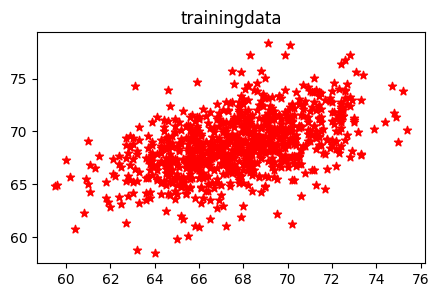

In [7]:
plt.figure(figsize=(5,3))
plt.title('trainingdata')
plt.scatter(X_train,y_train,color='r',marker='*')
plt.show()

In [8]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

In [9]:
reg.coef_

array([0.51076287])

In [10]:
reg.intercept_

np.float64(34.15131538233475)

In [11]:
predictions=reg.predict(X_train)
predictions

array([67.04444447, 68.32135166, 70.92624232, 68.5767331 , 67.7595125 ,
       69.75148771, 69.44502998, 69.59825884, 69.3939537 , 65.46107956,
       65.92076615, 67.24874962, 69.03641968, 71.02839489, 67.29982591,
       66.68691046, 70.67086088, 67.81058879, 69.64933513, 68.93426711,
       69.70041142, 67.3509022 , 66.22722388, 70.26225058, 67.3509022 ,
       69.90471657, 69.44502998, 68.9853434 , 69.03641968, 69.08749597,
       71.07947118, 69.18964855, 71.33485262, 70.21117429, 68.27027537,
       68.72996196, 70.92624232, 69.85364028, 67.24874962, 68.5767331 ,
       66.89121561, 69.44502998, 69.03641968, 66.99336819, 68.52565681,
       70.56870831, 68.72996196, 68.27027537, 69.3939537 , 69.54718256,
       67.24874962, 68.52565681, 66.78906304, 69.24072483, 68.83211453,
       67.60628364, 67.7595125 , 68.62780938, 67.19767334, 67.40197849,
       68.78103825, 70.72193717, 70.36440316, 69.24072483, 68.72996196,
       69.3939537 , 67.65735992, 69.85364028, 67.81058879, 66.17

In [12]:
training_data['model_predict_values']=predictions
training_data

,X_train_values,y_train_values,model_predict_values
875,64.4,65.2,67.044444
949,66.9,67.7,68.321352
618,72.0,71.8,70.926242
881,67.4,64.8,68.576733
590,65.8,71.0,67.759512
...,...,...,...
330,67.3,68.9,68.525657
466,67.6,66.3,68.678886
121,69.2,68.9,69.496106
1044,69.3,71.9,69.547183


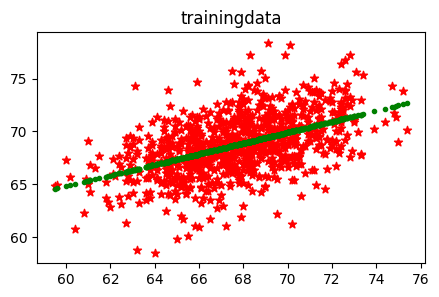

In [13]:
plt.figure(figsize=(5,3))
plt.title('trainingdata')
plt.scatter(X_train,y_train,color='r',marker='*')
plt.scatter(X_train,predictions,color='g',marker='.')
plt.show()

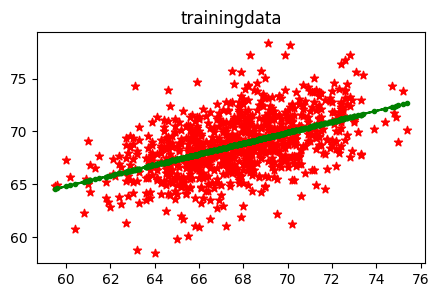

In [14]:
plt.figure(figsize=(5,3))
plt.title('trainingdata')
plt.scatter(X_train,y_train,color='r',marker='*')
plt.plot(X_train,predictions,color='g',marker='.')
plt.show()

In [15]:
s=0
for i in training_data.index:
  s += (training_data['y_train_values'][i]-training_data['model_predict_values'][i])**2
print(s/len(X_train))

6.1677268021122735


In [16]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_train,predictions)

6.167726802112276

In [17]:
numerator=0
denominator=0
for i in training_data.index:
  numerator += (training_data['y_train_values'][i]-training_data['model_predict_values'][i])**2
  denominator += (training_data['y_train_values'][i]-y_train.mean())**2
print(1-(numerator)/denominator)

0.2458882545509915


In [18]:
from sklearn.metrics import r2_score
r2_score(y_train,predictions)

0.24588825455099228

In [19]:
model_predicts=reg.predict(X_test)
model_predicts

array([71.89669178, 68.83211453, 68.78103825, 71.33485262, 67.3509022 ,
       69.95579286, 69.29180112, 70.16009801, 70.56870831, 68.21919908,
       70.05794543, 69.95579286, 71.69238663, 67.09552076, 69.70041142,
       67.96381765, 69.08749597, 68.67888567, 70.26225058, 67.70843621,
       67.7595125 , 69.90471657, 67.86166507, 70.36440316, 69.13857226,
       69.44502998, 70.82408974, 70.72193717, 67.81058879, 67.65735992,
       68.06597022, 68.5767331 , 67.50413106, 68.83211453, 70.51763202,
       70.41547944, 67.7595125 , 68.27027537, 69.54718256, 70.56870831,
       70.21117429, 68.5767331 , 68.88319082, 68.88319082, 69.85364028,
       68.06597022, 68.72996196, 68.1681228 , 67.91274136, 68.5767331 ,
       69.85364028, 69.03641968, 69.08749597, 70.31332687, 69.64933513,
       67.19767334, 69.49610627, 69.03641968, 66.43152903, 67.91274136,
       68.67888567, 69.70041142, 64.54170639, 66.58475789, 67.40197849,
       69.85364028, 67.86166507, 67.14659705, 69.85364028, 71.43

In [20]:
testing_data['model_predict_test_values']=model_predicts
testing_data

,X_test_values,y_test_values,model_predict_test_values
423,73.9,70.0,71.896692
548,67.9,69.0,68.832115
837,67.8,73.6,68.781038
587,72.8,70.6,71.334853
864,65.0,63.5,67.350902
...,...,...,...
1046,70.2,72.6,70.006869
913,64.6,67.5,67.146597
679,67.3,66.3,68.525657
409,70.5,72.9,70.160098


In [21]:
s=0
for i in testing_data.index:
  s += (testing_data['y_test_values'][i]-testing_data['model_predict_test_values'][i])**2
print(s/len(X_test))

5.006602109017909


In [22]:
mean_squared_error(y_test,model_predicts)

5.0066021090179085

In [23]:
numerator=0
denominator=0
for i in testing_data.index:
  numerator += (testing_data['y_test_values'][i]-testing_data['model_predict_test_values'][i])**2
  denominator += (testing_data['y_test_values'][i]-y_test.mean())**2
print(1-(numerator)/denominator)

0.26784157787744


In [24]:
r2_score(y_test,model_predicts)

0.2678415778774407

'''''

In [25]:
import warnings
warnings.filterwarnings('ignore')
reg.predict([[60]])

array([64.79708783])

In [26]:
import pickle
with open('SLR_TASK.pkl','wb') as f:
  pickle.dump(reg,f)